In [2]:
# Mount Google Drive folder as a local folder
# Note: This mounts your entire drive, not the current folder
from google.colab import drive
drive.mount('/mydrive')

Mounted at /mydrive


In [3]:
#TODO replace the path with your path in drive
#This usually takes 15-20 minutes to run
!cp -r /mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset ./

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import shutil

import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Sequential, Model

In [5]:
# TRAIN_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/train/'
# TEST_PATH = '../input/fruits-fresh-and-rotten-for-classification/dataset/test/'
TRAIN_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/train/'
TEST_PATH = '/mydrive/MyDrive/Colab_Notebooks/CV/CV_project/dataset/test/'
SIZE = (224, 224)

In [6]:
labels = []
for class_ in os.listdir(TRAIN_PATH):
    labels.append(class_)
NUM_LABELS = len(labels)

print(labels)

['freshapples', 'freshbanana', 'freshoranges', 'rottenapples', 'rottenbanana', 'rottenoranges']


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen=ImageDataGenerator(rescale=1./255, validation_split = 0.1)
test_datagen = ImageDataGenerator(rescale=1./255)

'''
Comments:
- ImageDataGenerator will resize all images to target_size
- x_col is the column where the images' names are
- y_col is the column where the labels are
- has_ext means that the images' names include a file extension, e.g. image_name.jpg
- Here you can change the targe_size to resize all images to different shapes.
Maybe larger images help in getting a better accuracy
'''
train_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TRAIN_PATH,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="training",
                                                 class_mode='categorical')

val_dataset = datagen.flow_from_directory(batch_size=32,
                                                 directory=TEST_PATH ,
                                                 shuffle=True,
                                                classes=labels,
                                                 target_size=SIZE,
                                                 subset="validation",
                                                 class_mode='categorical')

Found 9813 images belonging to 6 classes.
Found 268 images belonging to 6 classes.


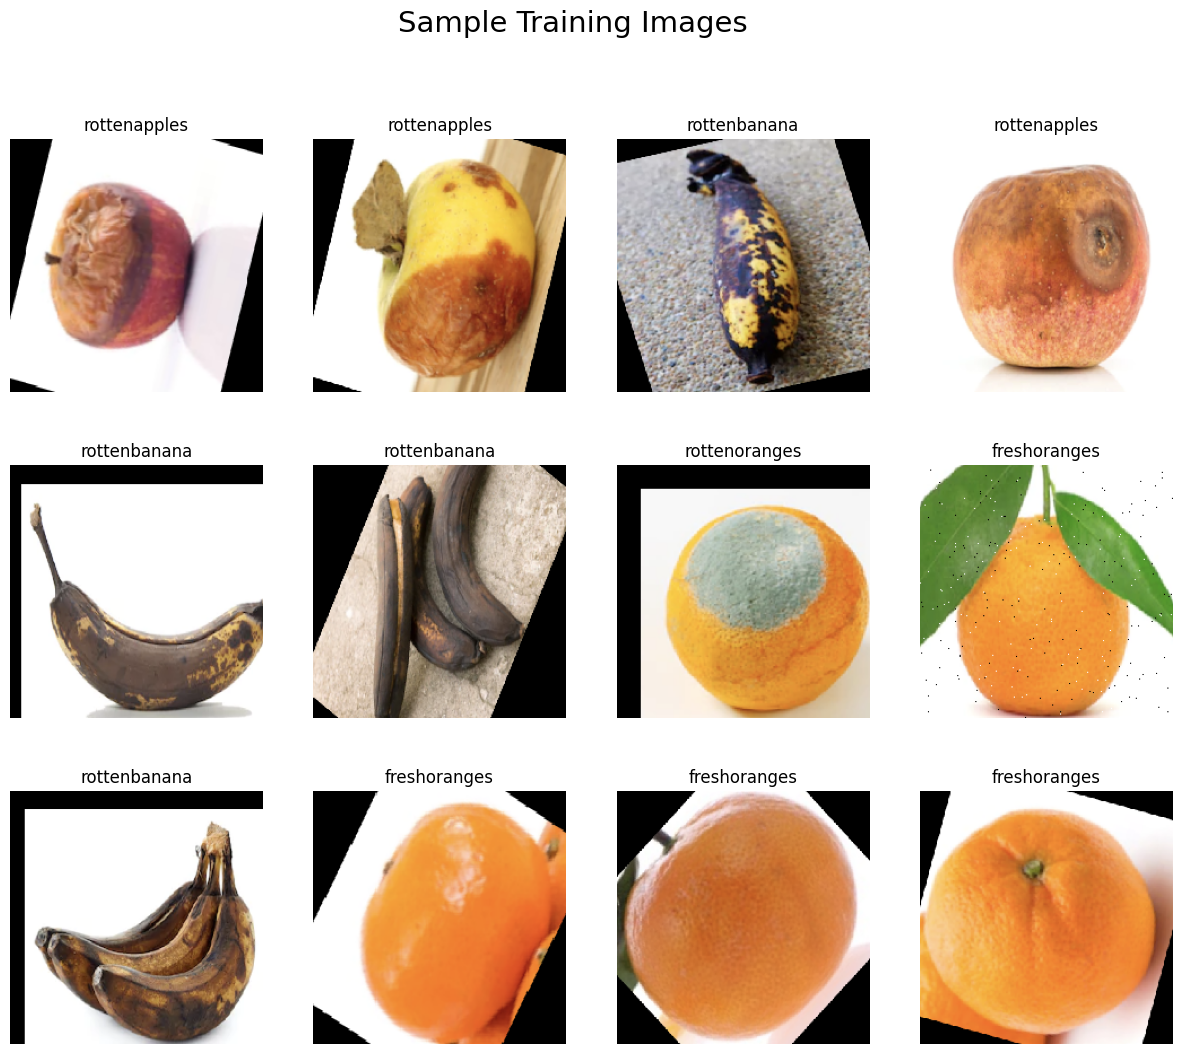

In [8]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(15, 12))
idx = 0

for i in range(3):
    for j in range(4):
        label = labels[np.argmax(train_dataset[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_dataset[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

# plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [9]:
from keras.applications.densenet import DenseNet121

In [10]:
from keras.models import Model
from keras.layers import Input, Dense
from tensorflow.keras.optimizers import  Adam


In [11]:
model = DenseNet121(
    include_top=True,
    weights=None,
    input_tensor=Input(shape=(224, 224, 3)),
    input_shape=None,
    pooling=None,
    classes=6,
)


In [12]:

from keras.callbacks import LearningRateScheduler

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
import keras
from keras.layers import *
from keras.models import *
from keras.preprocessing import image
from keras.callbacks import EarlyStopping
from keras.callbacks import ModelCheckpoint

In [14]:
model.compile(loss='categorical_crossentropy',optimizer="adam",metrics=['accuracy'])
model.summary()
epochs = 30
stepsperepoch=187
validationsteps=1
annealer = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
es = EarlyStopping(monitor='val_acc', mode='max', verbose=1, patience=100)
mc = ModelCheckpoint("densenet121.h5", monitor='val_loss',save_best_only=True, mode='min',verbose=1)

Model: "densenet121"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 7,043,654 (26.87 MB)

 Trainable params: 6,960,006 (26.55 MB)

 Non-trainable params: 83,648 (326.75 KB)

In [15]:
hist = model.fit(
    train_dataset,
    epochs=epochs,
    callbacks=[annealer,mc,es],
    steps_per_epoch=stepsperepoch,
    validation_data=val_dataset,
    validation_steps = validationsteps
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 664ms/step - accuracy: 0.7144 - loss: 0.8293
Epoch 1: val_loss improved from inf to 6.90161, saving model to densenet121.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 293s 736ms/step - accuracy: 0.7148 - loss: 0.8282 - val_accuracy: 0.2500 - val_loss: 6.9016 - learning_rate: 0.0010
Epoch 2/30
  2/187 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.8203 - loss: 0.3945

...

187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9791 - loss: 0.0623 - val_accuracy: 0.9375 - val_loss: 0.0650 - learning_rate: 4.1812e-04
Epoch 19/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9834 - loss: 0.0479
Epoch 19: val_loss did not improve from 0.06498
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.9834 - loss: 0.0479 - val_accuracy: 0.9062 - val_loss: 0.1784 - learning_rate: 3.9721e-04
Epoch 20/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 191ms/step - accuracy: 0.9855 - loss: 0.0410
Epoch 20: val_loss improved from 0.06498 to 0.06081, saving model to densenet121.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.9860 - loss: 0.0407 - val_accuracy: 0.9688 - val_loss: 0.0608 - learning_rate: 3.7735e-04
Epoch 21/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9860 - loss: 0.0413
Epoch 21: val_loss did not improve from 0.06081
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9859 - loss: 0.0413 - val_accuracy: 0.5938 - val_loss: 4.0757 - learning_rate: 3.5849e-04
Epoch 22/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.9818 - loss: 0.0570
Epoch 22: val_loss did not improve from 0.06081
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.9838 - loss: 0.0514 - val_accuracy: 0.9688 - val_loss: 0.1356 - learning_rate: 3.4056e-04
Epoch 23/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step - accuracy: 0.9870 - loss: 0.0403
Epoch 23: val_loss did not improve from 0.06081
187/187 ━━━━━━━━━━━━━━━━━━━━ 36s 192ms/step - accuracy: 0.9869 - loss: 0.0404 - val_accuracy: 0.9375 - val_loss: 0.2069 - learning_rate: 3.2353e

187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9817 - loss: 0.0542 - val_accuracy: 0.9688 - val_loss: 0.0475 - learning_rate: 3.0736e-04
Epoch 25/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9893 - loss: 0.0387
Epoch 25: val_loss did not improve from 0.04754
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9893 - loss: 0.0387 - val_accuracy: 0.9688 - val_loss: 0.0725 - learning_rate: 2.9199e-04
Epoch 26/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 189ms/step - accuracy: 0.9951 - loss: 0.0184
Epoch 26: val_loss improved from 0.04754 to 0.02738, saving model to densenet121.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9954 - loss: 0.0177 - val_accuracy: 1.0000 - val_loss: 0.0274 - learning_rate: 2.7739e-04
Epoch 27/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.9919 - loss: 0.0252
Epoch 27: val_loss did not improve from 0.02738
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 195ms/step - accuracy: 0.9919 - loss: 0.0252 - val_accuracy: 0.9375 - val_loss: 0.0844 - learning_rate: 2.6352e-04
Epoch 28/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 190ms/step - accuracy: 0.9908 - loss: 0.0318
Epoch 28: val_loss improved from 0.02738 to 0.00854, saving model to densenet121.h5


187/187 ━━━━━━━━━━━━━━━━━━━━ 24s 130ms/step - accuracy: 0.9913 - loss: 0.0294 - val_accuracy: 1.0000 - val_loss: 0.0085 - learning_rate: 2.5034e-04
Epoch 29/30
187/187 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.9924 - loss: 0.0219
Epoch 29: val_loss did not improve from 0.00854
187/187 ━━━━━━━━━━━━━━━━━━━━ 37s 196ms/step - accuracy: 0.9924 - loss: 0.0219 - val_accuracy: 1.0000 - val_loss: 0.0100 - learning_rate: 2.3783e-04
Epoch 30/30
120/187 ━━━━━━━━━━━━━━━━━━━━ 12s 194ms/step - accuracy: 0.9956 - loss: 0.0171
Epoch 30: val_loss did not improve from 0.00854
187/187 ━━━━━━━━━━━━━━━━━━━━ 23s 126ms/step - accuracy: 0.9954 - loss: 0.0172 - val_accuracy: 0.9688 - val_loss: 0.0684 - learning_rate: 2.2594e-04


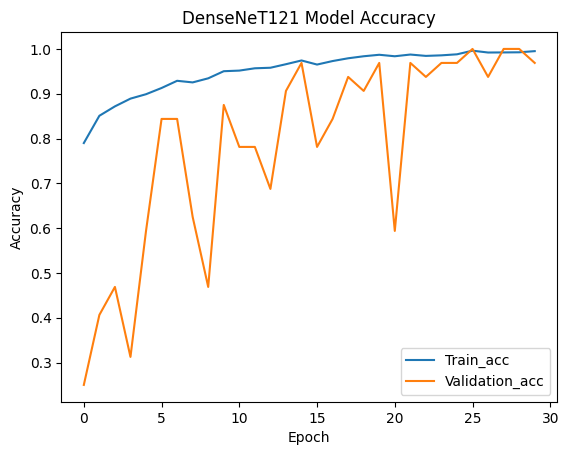

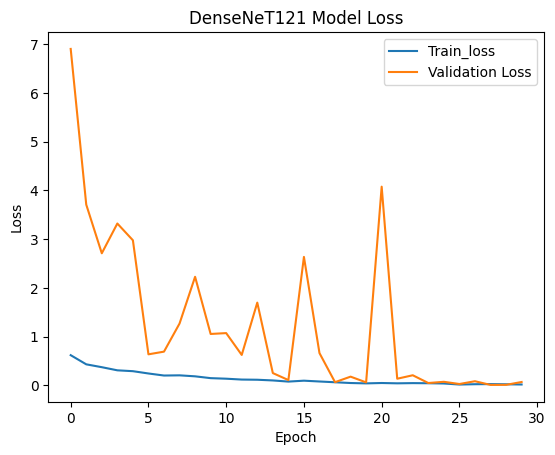

In [16]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('DenseNeT121 Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(["Train_acc","Validation_acc"])
plt.show()

plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('DenseNeT121 Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(["Train_loss","Validation Loss"])
plt.show()

In [17]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(TEST_PATH,
                                                  batch_size=1,
                                                  target_size=SIZE,
                                                  shuffle = False,
                                                  classes=labels,
                                                  class_mode='categorical')


filenames = test_generator.filenames
nb_samples = len(filenames)

loss, acc = model.evaluate(test_generator,steps = (nb_samples), verbose=1)
print('accuracy test: ',acc)
print('loss test: ',loss)

Found 2698 images belonging to 6 classes.
2698/2698 ━━━━━━━━━━━━━━━━━━━━ 35s 10ms/step - accuracy: 0.9939 - loss: 0.0160
accuracy test:  0.9911045432090759
loss test:  0.021250050514936447


In [18]:
predictions = model.predict(test_generator)
files=test_generator.filenames
class_dict=test_generator.class_indices # a dictionary of the form class name: class index
rev_dict={}
for key, value in class_dict.items():
    rev_dict[value]=key

for i, p in enumerate(predictions):
    index=np.argmax(p)
    klass=rev_dict[index]
    prob=p[index]

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


2698/2698 ━━━━━━━━━━━━━━━━━━━━ 34s 9ms/step


In [19]:
print(len(test_generator[0][0]))
print(test_generator[0][1].shape)

1
(1, 6)


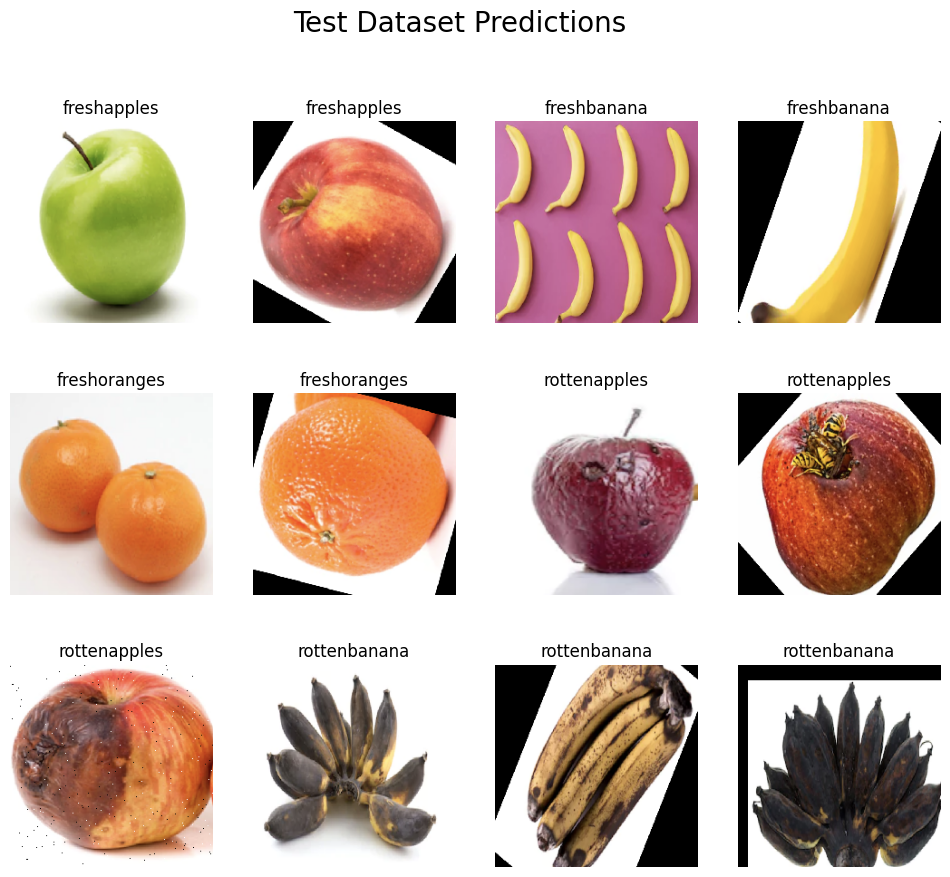

In [20]:
fig, ax = plt.subplots(nrows=3, ncols=4, figsize=(12, 10))
idx = 0

for i in range(3):
    for j in range(4):
        predicted_label = labels[np.argmax(predictions[idx])]
        ax[i, j].set_title(f"{predicted_label}")
        ax[i, j].imshow(test_generator[idx][0].reshape(224,224,3))
        ax[i, j].axis("off")
        idx += 200

# plt.tight_layout()
plt.suptitle("Test Dataset Predictions", fontsize=20)
plt.show()

In [21]:
# from keras.utils.vis_utils import plot_model
# tf.keras.utils.plot_model(
# model, to_file='model.png', show_shapes=True, show_dtype=False,
# show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
# )
from tensorflow.keras.utils import plot_model # Importing plot_model from the correct module

tf.keras.utils.plot_model(
model, to_file='model.png', show_shapes=True, show_dtype=False,
show_layer_names=True, rankdir='TB', expand_nested=False, dpi=96
)

Output hidden; open in https://colab.research.google.com to view.

In [22]:
!pip install visualkeras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.4/997.4 kB 13.0 MB/s eta 0:00:00


In [23]:
from tensorflow.keras import layers
from collections import defaultdict
# from PIL import ImageFont
# font = ImageFont.truetype("arial.ttf", 12)
color_map = defaultdict(dict) #customize the colours
color_map[layers.Conv2D]['fill'] = '#00f5d4'
color_map[layers.MaxPooling2D]['fill'] = '#8338ec'
color_map[layers.Dropout]['fill'] = '#03045e'
color_map[layers.Dense]['fill'] = '#fb5607'
color_map[layers.Flatten]['fill'] = '#ffbe0b'
# visualkeras.layered_view(model, legend=True,color_map=color_map,scale_xy=2, scale_z=1, max_z=200)

In [24]:
test_steps_per_epoch = np.ceil(test_generator.samples / test_generator.batch_size)
test_steps_per_epoch = int(test_steps_per_epoch)

In [ ]:
a

In [25]:

predictions = model.predict(test_generator, steps=test_steps_per_epoch)
# Get most likely class
predicted_classes = np.argmax(predictions, axis=1)

2698/2698 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step


In [26]:
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

In [27]:
from sklearn.metrics import classification_report,confusion_matrix
report = classification_report(true_classes, predicted_classes, target_names=class_labels)
print(report)

               precision    recall  f1-score   support

  freshapples       0.98      1.00      0.99       395
  freshbanana       1.00      0.99      1.00       381
 freshoranges       0.99      0.99      0.99       388
 rottenapples       1.00      0.97      0.98       601
 rottenbanana       1.00      1.00      1.00       530
rottenoranges       0.97      1.00      0.98       403

     accuracy                           0.99      2698
    macro avg       0.99      0.99      0.99      2698
 weighted avg       0.99      0.99      0.99      2698



In [28]:
print('Confusion Matrix')
# print(confusion_matrix(test_generator.classes, predicted_classes))
cm = confusion_matrix(test_generator.classes, predicted_classes)

Confusion Matrix


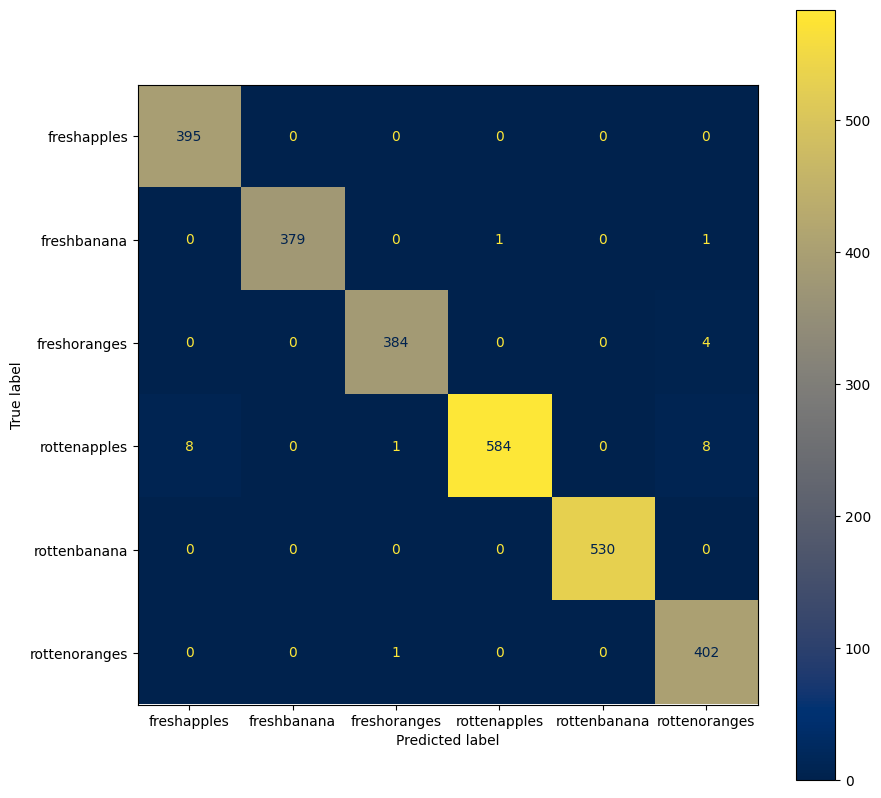

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(test_generator.classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
fig, ax = plt.subplots(figsize=(10,10))
disp.plot(ax=ax,cmap="cividis")